# Training

- Problem: **Autoregressive**
- Mesh: **Structured**
- Data shape: **0D + 2D -> 2D**
- Normalization: **MinMax**
- TT split: Simple **80-train/20-validation split, with 2 cases for test**
- Training input: **Re, current snapshot**
- Training output: **Next snapshot**
- Model: **FFN, CNN (UNet with injection at bottleneck)**
- Validation: **From snapshot 0, qualitative, MSE**

In [2]:
import sys
from pathlib import Path

import torch
import h5py
import importlib
import numpy as np
from tqdm import tqdm
from ipywidgets import interact
import matplotlib.pyplot as plt

# Normalization
from fluidlearn.cfdml.models_utils import Normalize
from sklearn.preprocessing import MinMaxScaler
# Dataset creation
from fluidlearn.cfdml.models_utils import Dataset0D2D
# Batch size and dataloaders
from torch.utils.data import DataLoader
# TT split
from sklearn.model_selection import train_test_split
# Training
import fluidlearn.cfdml.models
# Plotting
from fluidlearn.cfdml.plot_utils import interactive_side_by_side

In [3]:
RANDOM_STATE = 42
# np.random.seed(RANDOM_STATE)
TEST_SIZE = 0.2
BATCH_SIZE = 16

LOSS = torch.nn.MSELoss
OPTIMIZER = lambda model: torch.optim.AdamW(model.parameters(), lr=1e-3)
EPOCHS = 500
EPOCH_PLOT_INTERVAL = 25

DATASET_INPUT = "cylinder96"
dataset_path = Path.cwd().parent / f"data/01_raw/{DATASET_INPUT}"

In [4]:
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)             # CPU
torch.cuda.manual_seed(RANDOM_STATE)        # GPU
torch.cuda.manual_seed_all(RANDOM_STATE)    # Multi-GPU

In [4]:
### Load data

cases = sorted([file.name for file in dataset_path.iterdir() if file.suffix == ".h5"], key=lambda x: float(x.split(".")[0]))
chosen_cases = np.linspace(0, len(cases)-1, 20).astype(int)
data_bycase = [] # Structure: case_name -> snapshot -> input / output -> input scalars / input fields // target fields

for case_name in chosen_cases:#range(len(cases))
    case_path = dataset_path / cases[case_name]
    
    with h5py.File(case_path, "r") as file:
        Ux = file['Ux'][:]
        Uy = file['Uy'][:]
        p = file['p'][:]
        # Access attributes
        Re = file.attrs['Reynolds']

    N = len(Ux) # Number of snapshots. We can make N-1 data points
    data_bycase.append([
        np.tile([Re], (N-1, 1)),                            # Input scalars
        np.stack([Ux[:N-1], Uy[:N-1], p[:N-1]], axis=1),    # Input fields
        np.stack([Ux[1:N], Uy[1:N], p[1:N]], axis=1),       # Target fields
    ])

data_bycase_train = data_bycase# = [data_bycase[i] for i in [0, 1, 3, 4, 6, 7]] # Save two for test, 2 and 5
data_raw = [
    np.concatenate([case_name[0] for case_name in data_bycase_train]),  # Input scalars
    np.concatenate([case_name[1] for case_name in data_bycase_train]),  # Input fields
    np.concatenate([case_name[2] for case_name in data_bycase_train]),  # Target fields
]

width = data_raw[1].shape[-1]
height = data_raw[1].shape[-2]

In [5]:
# ### Normalization
# scalers = [ Normalize(MinMaxScaler()) for entry in data_raw ]
# data = [ scaler.fit_transform(entry) for scaler, entry in zip(scalers, data_raw) ]

# ### Dataset creation
# data = Dataset0D2D(input_scalars=data[0], input_fields=data[1], output=data[2])
# print(f"Dataset size: {len(data)}")

# ### TT Split https://www.kaggle.com/discussions/general/448072
# train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

# ### Define batch size and create DataLoaders
# train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
# val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

# for X, y in val_dataloader:
#     print(f"Shape of X scalar [BATCH_SIZE, SCALARS]: {X[0].shape}")
#     print(f"Shape of X fields [BATCH_SIZE, CHANNELS, HEIGHT, WIDTH]: {X[1].shape}")
#     print(f"Shape of y [BATCH_SIZE, CHANNELS, HEIGHT, WIDTH]: {y.shape} {y.dtype}")
#     break

In [6]:
### Normalization scalers based on training data only
scalers = [ Normalize(MinMaxScaler()) for entry in data_raw ]
indices = np.arange(len(data_raw[0]))
train_indices, _ = train_test_split(indices, test_size=TEST_SIZE, random_state=RANDOM_STATE)
scalers[0].fit(data_raw[0][train_indices].copy()) # Input scalars
scalers[1].fit(data_raw[1][train_indices].copy()) # Input fields
scalers[2].fit(data_raw[1][train_indices].copy()) # Target fields (same as input fields)

### Apply normalization
data = [ scaler.transform(entry) for scaler, entry in zip(scalers, data_raw) ]

### Dataset creation
data = Dataset0D2D(input_scalars=data[0], input_fields=data[1], output=data[2])
print(f"Dataset size: {len(data)}")

### TT Split https://www.kaggle.com/discussions/general/448072
train_data, val_data = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE)

### Define batch size and create DataLoaders
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

for X, y in val_dataloader:
    print(f"Shape of X scalar [BATCH_SIZE, SCALARS]: {X[0].shape}")
    print(f"Shape of X fields [BATCH_SIZE, CHANNELS, HEIGHT, WIDTH]: {X[1].shape}")
    print(f"Shape of y [BATCH_SIZE, CHANNELS, HEIGHT, WIDTH]: {y.shape} {y.dtype}")
    break

Dataset size: 2000
Shape of X scalar [BATCH_SIZE, SCALARS]: torch.Size([16, 1])
Shape of X fields [BATCH_SIZE, CHANNELS, HEIGHT, WIDTH]: torch.Size([16, 3, 32, 64])
Shape of y [BATCH_SIZE, CHANNELS, HEIGHT, WIDTH]: torch.Size([16, 3, 32, 64]) torch.float32


In [7]:
### Training
importlib.reload(cfdml.models)
from cfdml.models import UNet

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
model = UNet(loss=LOSS, device=device).to(device)

input_data = (torch.zeros(1, 1).to(device), torch.zeros(1, 3, height, width).to(device))
model.summary(input_data)

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [1, 3, 32, 64]            --
├─Sequential: 1-1                        [1, 32, 32, 64]           --
│    └─Conv2d: 2-1                       [1, 32, 32, 64]           896
│    └─ReLU: 2-2                         [1, 32, 32, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 32, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 32, 64]           --
├─Sequential: 1-2                        [1, 64, 16, 32]           --
│    └─MaxPool2d: 2-5                    [1, 32, 16, 32]           --
│    └─Conv2d: 2-6                       [1, 64, 16, 32]           18,496
│    └─ReLU: 2-7                         [1, 64, 16, 32]           --
│    └─Conv2d: 2-8                       [1, 64, 16, 32]           36,928
│    └─ReLU: 2-9                         [1, 64, 16, 32]           --
├─Sequential: 1-3                        [1, 128, 8, 16]           --
│  

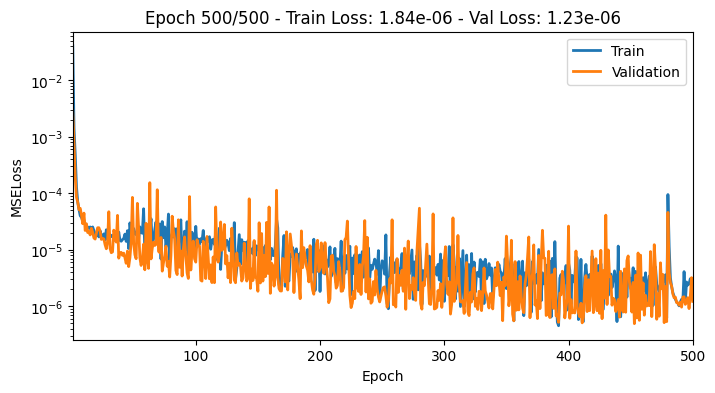

Training: 100%|██████████| 500/500 [11:57<00:00,  1.43s/epoch, train_loss=1.84e-6, val_loss=1.23e-6]


In [8]:
history = model.fit(
    train_dataloader,
    val_dataloader,
    epochs=EPOCHS,
    optimizer=OPTIMIZER,
    epoch_plot_interval=EPOCH_PLOT_INTERVAL
)

In [9]:
# def fit_autoregressive(
#         self,
#         dataloader_list,
#         validation_cases,
#         epochs,
#         optimizer = lambda model: torch.optim.AdamW(model.parameters(), lr=1e-3),
#         epoch_plot_interval = None
#     ):
#         self.optimizer = optimizer(self)
#         best_val_loss = float("inf")
#         best_weights = None

#         self.history = {"train_loss": [], "val_loss": []}
#         progress_bar = tqdm(range(epochs), desc="Training", unit="epoch")
#         for epoch in progress_bar:
#             train_loss = 0
#             for case_id, dataloader in enumerate(dataloader_list):
#                 if case_id in validation_cases:
#                     continue
                
#                 # Training
#                 self.train()
#                 X, y = next(iter(dataloader))
#                 scalars, fields = self.X_to_device(X, self.device)
#                 count = 0
#                 # for _, y_snap in dataloader:
#                 #     # if count == 2: break
#                 #     count += 1
#                 #     X_snap, y_snap = (scalars, fields), y_snap.to(self.device)
#                 #     # Zero parameter gradients
#                 #     self.optimizer.zero_grad()
#                 #     # Compute prediction error
#                 #     pred = self(X_snap)
#                 #     fields = pred.detach() # Next input is previous prediction. Detach to avoid gradient accumulation
#                 #     loss = self.loss(pred, y_snap)
#                 #     # Backpropagation
#                 #     loss.backward()
#                 #     self.optimizer.step()

#                 #     train_loss += loss.item()
#                 total_loss = 0
#                 #self.optimizer.zero_grad()
#                 for X_temp, y_snap in dataloader:
#                     #print(X_temp[0], y_snap.shape)
#                     #X_temp = X_temp[0].to(self.device)
#                     scalars, fields = self.X_to_device(X_temp, self.device)
#                     X_snap, y_snap = (scalars, fields), y_snap.to(self.device)
#                     self.optimizer.zero_grad()
#                     pred = self(X_snap)
#                     #total_loss += self.loss(pred, y_snap)
#                     loss = self.loss(pred, y_snap)
#                     loss.backward()
#                     self.optimizer.step()
#                     total_loss += loss.item()
#                     #fields = pred.detach()

#                 avg_loss = total_loss / len(dataloader)
#                 # avg_loss.backward()
#                 # self.optimizer.step()
                
#                 train_loss += avg_loss#.item()
#                 # train_loss /= len(dataloader)
#             train_loss /= len(dataloader_list) - len(validation_cases)
#             self.history["train_loss"].append(train_loss)

#             # Validation
#             # val_loss = self.validate(val_dataloader)
#             self.history["val_loss"].append(train_loss)
            
#             progress_bar.set_postfix(train_loss=train_loss, val_loss=train_loss)
            
#             if epoch_plot_interval is not None and epoch > 0:
#                 if epoch % epoch_plot_interval == 0 or epoch == epochs - 1:
#                     self.fit_plot(epoch, epochs)
        
#         return self.history

# UNet.fit_autoregressive = fit_autoregressive

# validation_cases = [10]
# dataloader_list = []
# for case_name in range(len(chosen_cases)):
#     x = [ scaler.transform(entry) for scaler, entry in zip(scalers, data_bycase[case_name]) ]
#     dataloader_list.append(DataLoader(Dataset0D2D(input_scalars=x[0], input_fields=x[1], output=x[2]), batch_size=1, shuffle=False))

# OPTIMIZER2 = lambda model: torch.optim.AdamW(model.parameters(), lr=1e-5)
# history = model.fit_autoregressive(
#     dataloader_list,
#     validation_cases,
#     epochs=2,#50,
#     optimizer=OPTIMIZER2,
#     epoch_plot_interval=10
# )

In [10]:
def predict_autoregressive(self, test_dataloader, n_snaps, progress_bar=True):
    self.eval()
    predictions_snaps = []

    with torch.no_grad():
        X = next(iter(test_dataloader)) # Only the first snapshot is used
        scalars, fields = self.X_to_device(X, self.device)

        progress_bar = tqdm(range(n_snaps), desc="Autoregressive prediction", unit="Snapshot", disable=not progress_bar)
        for _ in progress_bar:
            X_snap = (scalars, fields)
            pred = self(X_snap)
            
            fields = pred
            predictions_snaps.append(pred.cpu())

    return predictions_snaps

# Validate autoregression NO batches
def validate_autoregressive(self, val_dataloader, reduced_error=True, return_predictions=False, progress_bar=True):
    self.eval()
    predictions_snaps = []
    losses = []

    with torch.no_grad():
        X, _ = next(iter(val_dataloader))
        scalars, fields = self.X_to_device(X, self.device)

        progress_bar = tqdm(val_dataloader, desc="Autoregressive validation", unit="Snapshot", disable=not progress_bar)
        for _, y_snap in progress_bar:
            X_snap, y_snap = (scalars, fields), y_snap.to(self.device)
            pred = self(X_snap)

            fields[:,:3] = pred
            if reduced_error:losses.append(self.loss(pred, y_snap).item())
            else: losses.append(self.loss_no_reduction(pred, y_snap).cpu().numpy())
            if return_predictions: predictions_snaps.append(pred.cpu())

    if return_predictions: return losses, predictions_snaps
    return losses

UNet.validate_autoregressive = validate_autoregressive

In [ ]:
### Test. Cases 2 and 5 are not included in training
case_name = 3
N_case = len(data_bycase[case_name][0])

velocity = [
    np.sqrt(
        data_bycase[case_name][2][Frame][0]**2 +
        data_bycase[case_name][2][Frame][1]**2
    )
    for Frame in range(N_case)
]
velocity = np.stack(velocity, axis=0)
velocity_min, velocity_max = velocity.min(), velocity.max()

velocity_pred = np.zeros((N_case, height, width))
losses = np.zeros(N_case)

x = [ scaler.transform(entry) for scaler, entry in zip(scalers, data_bycase[case_name]) ]
# x[0] = np.tile(0.01, (N_case, 1)) # wrong Re on purpose
dataloader = DataLoader(Dataset0D2D(input_scalars=x[0], input_fields=x[1], output=x[2]), batch_size=1, shuffle=False)
losses, pred = model.validate_autoregressive(dataloader, return_predictions=True)

for Frame in range(N_case):
    predNP = scalers[2].inverse_transform(pred[Frame].numpy())[0]
    velocity_pred[Frame] = np.sqrt(predNP[0]**2+predNP[1]**2)


grid_x, grid_y = np.meshgrid(
    np.linspace(0, width, width),
    np.linspace(0, height, height)
)
minv, maxv = min(velocity.min(), velocity_pred.min()), max(velocity.max(), velocity_pred.max())
interactive_func = lambda Frame=0: interactive_side_by_side(
    lambda ax: ax.contourf(grid_x, grid_y, velocity[Frame], levels=100, cmap="jet", vmin=minv, vmax=maxv),
    lambda ax: ax.contourf(grid_x, grid_y, velocity_pred[Frame], levels=100, cmap="jet", vmin=minv, vmax=maxv),
    figsize=(12, 4),
    title_left="Ground truth",
    title_right=f"Prediction (MSE: {losses[Frame]:.6f})",
    title_overall=f"Case name: {case_name}. Re = {data_bycase[case_name][0][0][0].item():.2f}, t = {Frame} s",
    cbar_title_left="m/s",
    cbar_title_right="m/s"
)
interact(interactive_func, Frame=(0, N_case-1, 1))

Autoregressive validation: 100%|██████████| 100/100 [00:00<00:00, 224.73Snapshot/s]


interactive(children=(IntSlider(value=0, description='Frame', max=99), Output()), _dom_classes=('widget-intera…

<function __main__.<lambda>(Frame=0)>

In [ ]:
# for Frame in tqdm(range(N_case)):
#     interactive_side_by_side(
#         lambda ax: ax.contourf(grid_x, grid_y, velocity[Frame], levels=100, cmap="jet", vmin=minv, vmax=maxv),
#         lambda ax: ax.contourf(grid_x, grid_y, velocity_pred[Frame], levels=100, cmap="jet", vmin=minv, vmax=maxv),
#         figsize=(12, 4),
#         title_left="Ground truth",
#         title_right=f"Prediction (MSE: {losses[Frame]:.6f})",
#         title_overall=f"Re={data_bycase[case_name][0][0][0].item():.2f}, t={Frame} s",
#         cbar_title_left="m/s",
#         cbar_title_right="m/s",
#         save=True
#     )

  0%|          | 0/100 [00:00<?, ?it/s]


TypeError: interactive_side_by_side() got an unexpected keyword argument 'save'

In [49]:
def interactive_side_by_side(
        left_plot,
        right_plot,
        figsize=(10, 5),
        title_left="",
        title_right="",
        title_overall="",
        cbar_title_left=None,
        cbar_title_right=None,
        save=False
    ):
    """
    #### Example for contourf plots
    grid_x, grid_y = np.meshgrid(
        np.linspace(0, width, width),
        np.linspace(0, height, height)
    )
    interactive_func = lambda Frame=0: interactive_side_by_side(
        lambda ax: ax.contourf(grid_x, grid_y, velocity[Frame], levels=100, cmap="jet"),
        lambda ax: ax.contourf(grid_x, grid_y, velocity_pred[Frame], levels=100, cmap="jet"),
        figsize=(12, 4),
        title_left="Ground truth",
        title_right=f"Prediction (MSE: {losses[Frame]:.6f})",
        title_overall=f"Case name: {case_name}. Re = {data_bycase[case_name][0][0][0].item():.2f}, t = {Frame} s",
        cbar_title_left="m/s",
        cbar_title_right="m/s"
    )
    interact(interactive_func, Frame=(0, N_case-1, 1))

    #### Example for imshow plots
    interactive_func = lambda Frame=0: interactive_side_by_side(
        lambda ax: ax.imshow(velocity[Frame], extent=(0, width, 0, height), cmap="jet"),
        lambda ax: ax.imshow(velocity_pred[Frame], extent=(0, width, 0, height), cmap="jet"),
        figsize=(12, 4),
        title_left="Ground truth",
        title_right=f"Prediction (MSE: {losses[Frame]:.6f})",
        title_overall=f"Case name: {case_name}. Re = {data_bycase[case_name][0][0][0].item():.2f}, t = {Frame} s",
        cbar_title_left="m/s",
        cbar_title_right="m/s"
    )
    interact(interactive_func, Frame=(0, N_case-1, 1))
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    plt.suptitle(title_overall, fontsize=12)
    # Ground truth
    ax = axes[0]
    im = left_plot(ax)
    if cbar_title_left is not None:
        cbar = add_cbar(im, ax)
        cbar.ax.set_title(cbar_title_left)
    ax.set_title(title_left)

    # Prediction
    ax = axes[1]
    im = right_plot(ax)
    if cbar_title_right is not None:
        cbar = add_cbar(im, ax)
        cbar.ax.set_title(cbar_title_right)
    ax.set_title(title_right)

    plt.tight_layout()
    if save: 
        plt.savefig(f"output/{title_overall.replace(' ', '_')}.png", dpi=300)
        plt.close()
    else: plt.show()

from mpl_toolkits import axes_grid1

def add_cbar(im, ax, aspect=20, pad_fraction=0.5, **kwargs):
    """Add a vertical color bar to an image plot."""
    divider = axes_grid1.make_axes_locatable(im.axes)
    width = axes_grid1.axes_size.AxesY(im.axes, aspect=1./aspect)
    pad = axes_grid1.axes_size.Fraction(pad_fraction, width)
    cax = divider.append_axes("right", size=width, pad=pad)
    plt.sca(ax)
    return im.axes.figure.colorbar(im, cax=cax, **kwargs)

Autoregressive validation: 100%|██████████| 100/100 [00:00<00:00, 424.12Snapshot/s]


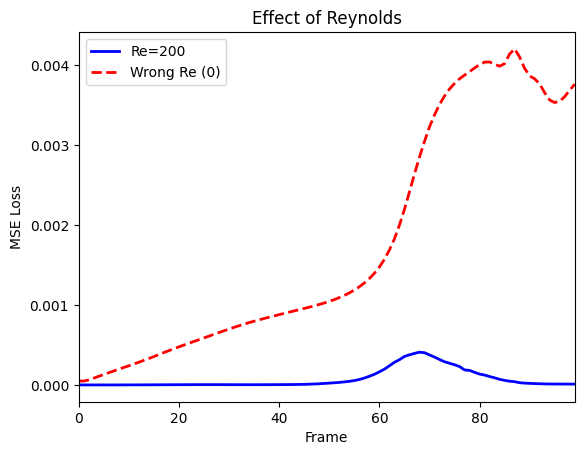

In [14]:
x[0] = np.tile(0, (N_case, 1)) # wrong Re on purpose
dataloader = DataLoader(Dataset0D2D(input_scalars=x[0], input_fields=x[1], output=x[2]), batch_size=1, shuffle=False)
losses_wrongRe = model.validate_autoregressive(dataloader)

plt.plot(losses, "b-", linewidth=2, label=f"Re={data_bycase[case_name][0][0][0].item():.0f}")
plt.plot(losses_wrongRe, "r--", linewidth=2, label="Wrong Re (0)")
plt.xlabel("Frame")
plt.ylabel("MSE Loss")
plt.xlim(0, N_case-1)
plt.title("Effect of Reynolds")
plt.legend(loc="upper left")
plt.show()

Autoregressive validation: 100%|██████████| 100/100 [00:00<00:00, 775.34Snapshot/s]


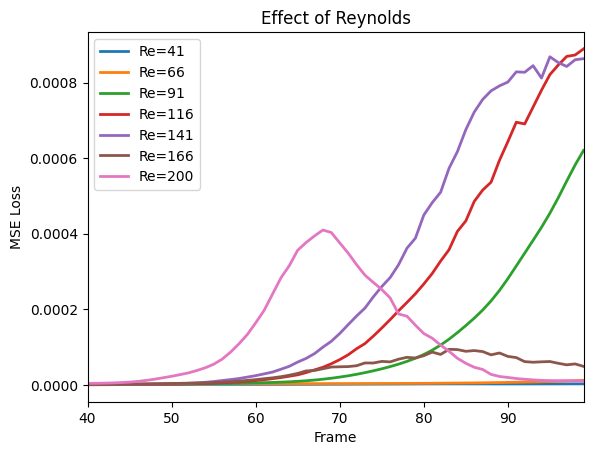

In [23]:
for i, case_name in enumerate([0, 3, 6, 9, 12, 15, 19]):
    N_case = len(data_bycase[case_name][0])

    velocity = [
        np.sqrt(
            data_bycase[case_name][2][Frame][0]**2 +
            data_bycase[case_name][2][Frame][1]**2
        )
        for Frame in range(N_case)
    ]
    velocity = np.stack(velocity, axis=0)
    velocity_min, velocity_max = velocity.min(), velocity.max()

    velocity_pred = np.zeros((N_case, height, width))
    losses = np.zeros(N_case)

    x = [ scaler.transform(entry) for scaler, entry in zip(scalers, data_bycase[case_name]) ]
    # x[0] = np.tile(0.01, (N_case, 1)) # wrong Re on purpose
    dataloader = DataLoader(Dataset0D2D(input_scalars=x[0], input_fields=x[1], output=x[2]), batch_size=1, shuffle=False)
    losses = model.validate_autoregressive(dataloader)

    Re = data_bycase[case_name][0][0][0].item()

    plt.plot(losses, linewidth=2, label=f"Re={Re:.0f}")
plt.xlabel("Frame")
plt.ylabel("MSE Loss")
plt.xlim(40, N_case-1)
plt.title("Effect of Reynolds")
plt.legend(loc="upper left")
plt.show()

In [24]:
# Permutation feature importance
# https://www.schlosslab.org/mikropml/reference/get_feature_importance.html
n_repeats = 10

Re = [case[0][0][0] for case in data_bycase]

baseline_loss_total = np.zeros(len(data_bycase))
baseline_loss_pixel = np.zeros((len(data_bycase), height, width))
for i, case in enumerate(data_bycase):
    x = [ scaler.transform(entry) for scaler, entry in zip(scalers, case) ]
    dataloader = DataLoader(Dataset0D2D(input_scalars=x[0], input_fields=x[1], output=x[2]), batch_size=1, shuffle=False)
    losses = model.validate_autoregressive(dataloader, progress_bar=False, reduced_error=False)
    baseline_loss_pixel[i] = np.mean(np.mean(losses, axis=2), axis=0)
    baseline_loss_total[i] = np.mean(losses)

permuted_loss_total = np.zeros((len(data_bycase), n_repeats))
permuted_loss_pixel = np.zeros((len(data_bycase), n_repeats, height, width))
for j in tqdm(range(n_repeats)):
    Re_permuted = np.random.permutation(Re)
    for i, case in enumerate(data_bycase):
        x = [ scaler.transform(entry) for scaler, entry in zip(scalers, case) ]
        x[0] = np.tile([Re_permuted[i]], (len(x[0]), 1)) # Permute Re
        dataloader = DataLoader(Dataset0D2D(input_scalars=x[0], input_fields=x[1], output=x[2]), batch_size=1, shuffle=False)
        losses = model.validate_autoregressive(dataloader, progress_bar=False, reduced_error=False)
        permuted_loss_pixel[i, j] = np.mean(np.mean(losses, axis=2), axis=0)
        permuted_loss_total[i, j] = np.mean(losses)
permuted_loss_pixel = np.mean(permuted_loss_pixel, axis=1)

baseline_loss = np.mean(baseline_loss_total)
permuted_loss = np.mean(permuted_loss_total)
permuted_loss_bycase = np.mean(permuted_loss_total, axis=1)
importance = np.mean(permuted_loss_total) - baseline_loss
pvalue = np.mean(np.mean(permuted_loss_total, axis=0) < baseline_loss)

# The p-value represents the probability of obtaining the actual performance in the event that the null hypothesis is true, 
# where the null hypothesis is that the feature is not important for model performance.
baseline_loss, importance, pvalue

100%|██████████| 10/10 [00:29<00:00,  2.90s/it]


(np.float64(6.72941960829121e-05),
 np.float64(0.2225438781708044),
 np.float64(0.0))

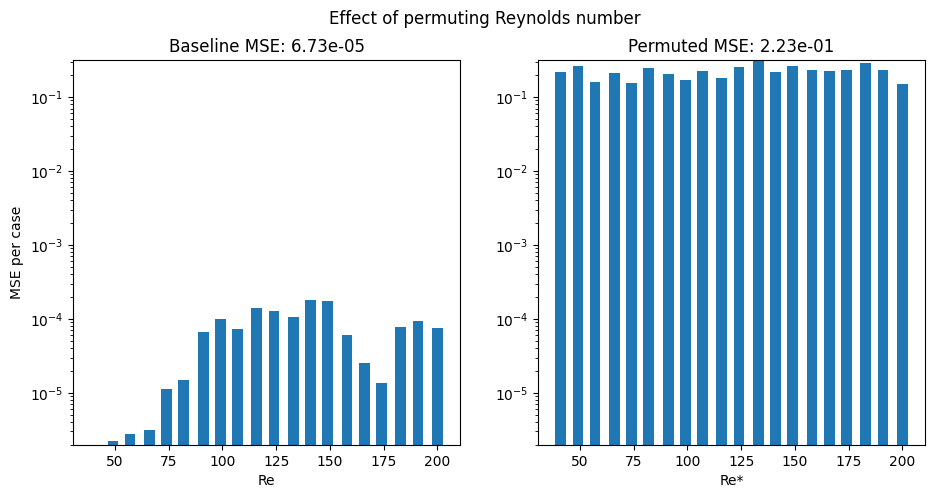

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

minmax = (min([baseline_loss_total.min(), permuted_loss_bycase.min()]), max([baseline_loss_total.max(), permuted_loss_bycase.max()]))
ax = axes[0]
ax.bar(Re, baseline_loss_total, width=5)
ax.set_ylim(minmax)
ax.set_yscale("log")
ax.set_ylabel("Case MSE")
ax.set_xlabel("Re")
ax.set_title(f"Baseline MSE: {baseline_loss:.2e}")

ax = axes[1]
ax.bar(Re, permuted_loss_bycase, width=5)
ax.set_ylim(minmax)
ax.set_yscale("log")
ax.set_xlabel("Re*")
ax.set_title(f"Permuted MSE: {permuted_loss:.2e}")

plt.suptitle("Effect of permuting Reynolds number")
plt.show()

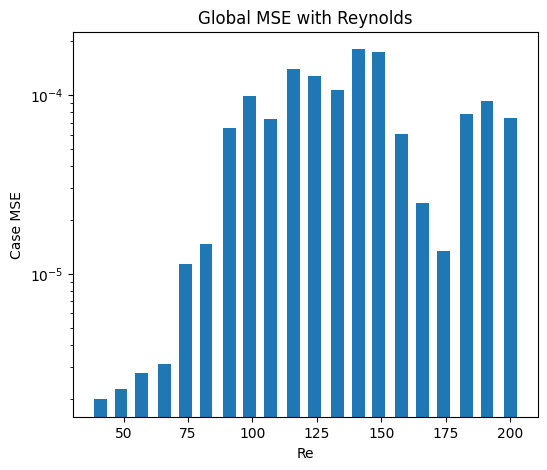

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.bar(Re, baseline_loss_total, width=5)
ax.set_yscale("log")
ax.set_ylabel("Case MSE")
ax.set_xlabel("Re")
ax.set_title(f"Global MSE with Reynolds")

plt.show()

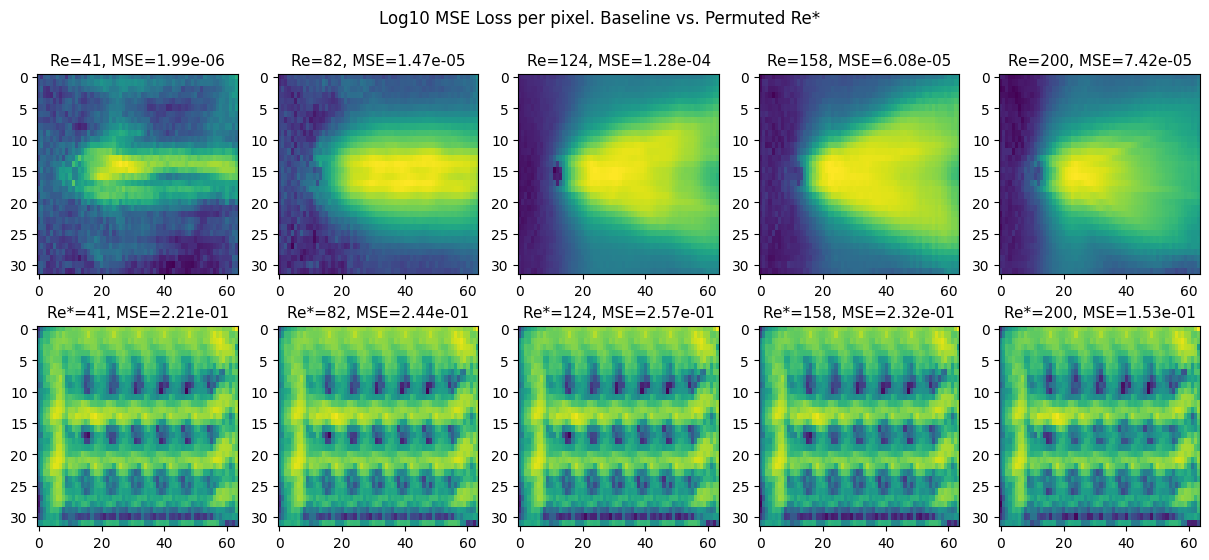

In [30]:
n_show = 5
chosen = np.round(np.linspace(0, len(data_bycase)-1, n_show)).astype(int)

fig, axes = plt.subplots(2, n_show, figsize=(3*n_show,6))
plt.suptitle("Log10 MSE Loss per pixel. Baseline vs. Permuted Re*")
for i, ax in enumerate(axes.flatten()):
    if i < n_show:
        index = chosen[i]
        ax.imshow(np.log10(baseline_loss_pixel[index]), cmap="viridis", aspect=2)
        ax.set_title(f"Re={Re[index]:.0f}, MSE={np.mean(baseline_loss_pixel[index]):.2e}", fontsize=11)
    else:
        index = chosen[i-n_show]
        ax.imshow(np.log10(permuted_loss_pixel[index]), cmap="viridis", aspect=2)
        ax.set_title(f"Re*={Re[index]:.0f}, MSE={np.mean(permuted_loss_pixel[index]):.2e}", fontsize=11)

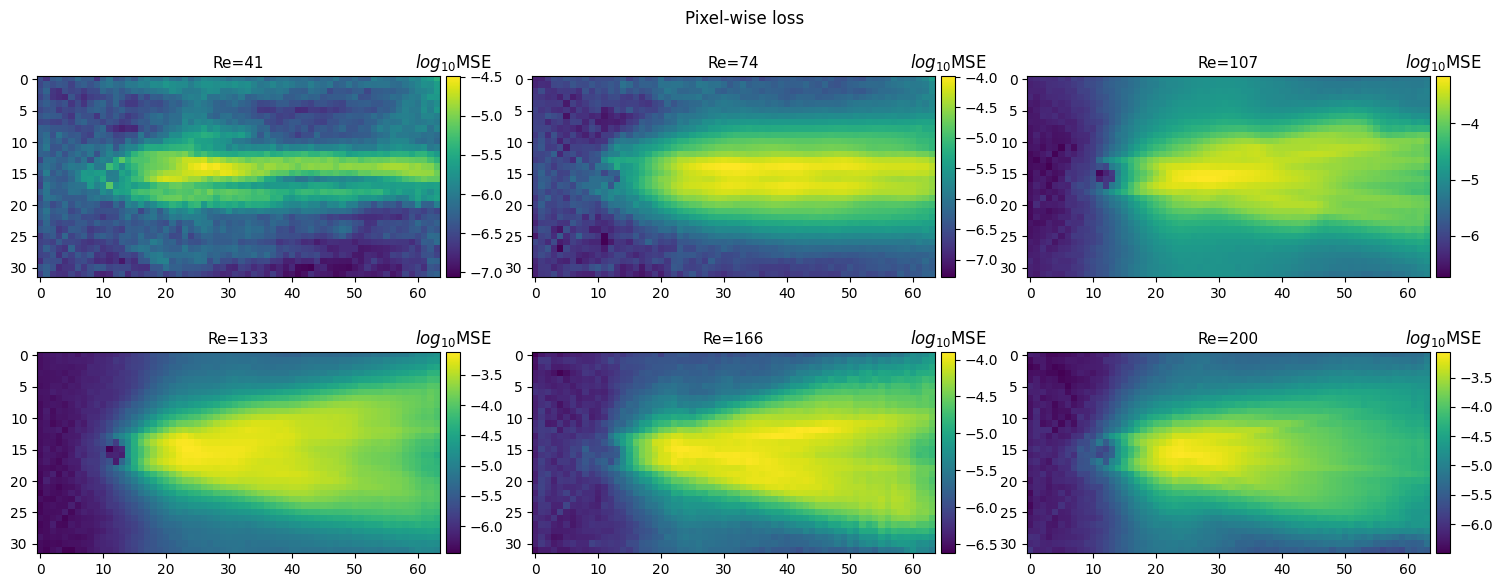

In [80]:
n_show = 6
chosen = np.round(np.linspace(0, len(data_bycase)-1, n_show)).astype(int)

fig, axes = plt.subplots(2, n_show // 2, figsize=(5*n_show//2,6))

for i, ax in enumerate(axes.flatten()):
    index = chosen[i]
    im = ax.imshow(np.log10(baseline_loss_pixel[index]), cmap="viridis", aspect=1)
    cbar = add_cbar(im, ax, aspect=15)
    cbar.ax.set_title("$log_{10}$MSE")
    ax.set_title(f"Re={Re[index]:.0f}", fontsize=11)

plt.suptitle("Pixel-wise loss")
plt.tight_layout()
plt.show()
    